## Imports

In [1]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Audio processing
import librosa
import librosa.display
import soundfile as sf

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# For plotting mel-spectrograms
import matplotlib.pyplot as plt

# Text processing
import unicodedata
from collections import Counter

# Progress bar
from tqdm.notebook import tqdm
import re
import unicodedata
import torch.nn.functional as F
from collections import Counter

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Cell A - Clear GPU memory

import torch, gc

if 'model' in globals():
    del model

gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print("Allocated:", round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")
    print("Reserved :", round(torch.cuda.memory_reserved() / 1024**3, 2), "GB")
else:
    print("CUDA not available")


Tesla P100-PCIE-16GB
Allocated: 0.0 GB
Reserved : 0.0 GB


## Load The Data

In [3]:
# Try to automatically detect the dataset directory
CANDIDATE_DIRS = [
    "/kaggle/input/hindi-tts/hindi-dataset",       # common Kaggle path
    "/kaggle/input/hindi-tts-dataset",   # alternative Kaggle name
    "./hindi-dataset",                   # local folder
    "/kaggle/input/hindi-tts/hindi-dataset/metadata.csv"    # current directory (if metadata.csv is here)
]

DATA_DIR = None
for path in CANDIDATE_DIRS:
    if os.path.isdir(path):
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find dataset folder. "
        "Please set DATA_DIR manually to the folder that contains metadata.csv and audio/."
    )

print("✅ Using DATA_DIR:", DATA_DIR)

# Path to metadata.csv
metadata_path = os.path.join(DATA_DIR, "metadata.csv")

# Load metadata (Hindi text → make sure encoding is UTF-8)
df = pd.read_csv(metadata_path, encoding="utf-8")

print("\n📄 Metadata loaded.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\n🔍 First 5 rows:")
display(df.head())

print("\n❓ Missing values per column:")
print(df.isnull().sum())


✅ Using DATA_DIR: /kaggle/input/hindi-tts/hindi-dataset

📄 Metadata loaded.
Shape: (11825, 2)
Columns: ['audio', 'text']

🔍 First 5 rows:


,audio,text
0,audio/recording_0.wav,"प्रसिद्द कबीर अध्येता, पुरुषोत्तम अग्रवाल का य..."
1,audio/recording_1.wav,"किन्तु आधुनिक पांडित्य, न सिर्फ़ एक ब्राह्मण र..."
2,audio/recording_2.wav,"उस पर, इन चार कवियों का गहरा असर है"
3,audio/recording_3.wav,इसे कई बार मंचित भी किया गया है
4,audio/recording_4.wav,"यहाँ प्रस्तुत है, हिन्दी कवि कथाकार, तेजी ग्रो..."



❓ Missing values per column:
audio    0
text     0
dtype: int64


## Text Column Detection + Basic EDA

✅ Detected text column: 'text'

📏 Text length (characters) stats:
count    11825.000000
mean        99.626047
std         73.660817
min         16.000000
25%         58.000000
50%         86.000000
75%        123.000000
max       1600.000000
Name: text_char_len, dtype: float64

📝 Sample Hindi sentences:


,text,text_char_len
8169,उन्होंने पहले ही वोट देने का विकल्प चुना.,41
900,लेकिन इस अवांछित नन्हीं के विवाह की पर्वतनुमा ...,102
8075,देवकीनंदन पांडे ने कई रेडियो नाटकों में भाग लि...,52
7625,"जहाँ मैं रहता था, वहाँ लोग खाना पकवाते थे, कपड...",112
2816,जो भी भारतीय कंपनियां अब गूगल और फ़ेसबुक पर वि...,111


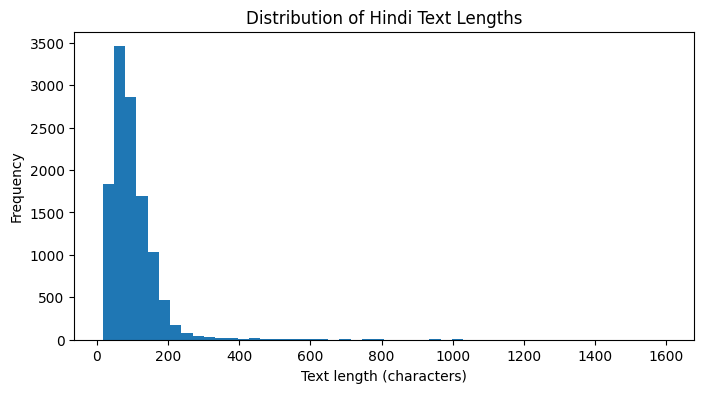

In [4]:
# Try to automatically detect the text column
TEXT_COL_CANDIDATES = [
    "text",
    "sentence",
    "transcription",
    "normalized_text",
    "hindi_text",
    "utt_text",
]

detected_text_col = None
for col in df.columns:
    if col.lower() in TEXT_COL_CANDIDATES:
        detected_text_col = col
        break

if detected_text_col is None:
    raise ValueError(
        "Could not automatically detect the text column.\n"
        "Please set 'detected_text_col' manually to the correct column name from:\n"
        f"{df.columns.tolist()}"
    )

print(f"✅ Detected text column: '{detected_text_col}'")

# For convenience, create a standard 'text' column (copy)
if detected_text_col != "text":
    df["text"] = df[detected_text_col].astype(str)
else:
    df["text"] = df["text"].astype(str)

# Basic text length stats (character-level)
df["text_char_len"] = df["text"].apply(len)

print("\n📏 Text length (characters) stats:")
print(df["text_char_len"].describe())

# Show a few random examples
print("\n📝 Sample Hindi sentences:")
display(df[["text", "text_char_len"]].sample(5, random_state=42))

# Plot histogram of text lengths
plt.figure(figsize=(8, 4))
plt.hist(df["text_char_len"], bins=50)
plt.xlabel("Text length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Hindi Text Lengths")
plt.show()


## Hindi Text Normalization + Vocabulary

In [5]:
import re
import unicodedata
from collections import Counter

def normalize_hindi_text(text):
    """
    Clean & normalize Hindi text:
    - Unicode normalize (NFC)
    - Remove unwanted characters
    - Standardize punctuation
    - Strip spaces
    """
    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Replace multiple spaces
    text = re.sub(r"\s+", " ", text)

    # Keep Hindi letters, matras, spaces, punctuation like । , .
    allowed = r"[^ऀ-ॿa-zA-Z0-9।,.!?\- ]"
    text = re.sub(allowed, "", text)

    return text.strip()


# Apply normalization
df["clean_text"] = df["text"].apply(normalize_hindi_text)

print("🧹 Text normalization done.")
display(df[["text", "clean_text"]].head())



# Build vocabulary (character-level)
all_text = "".join(df["clean_text"].tolist())
char_counts = Counter(all_text)

print("\n🔡 Total unique characters:", len(char_counts))
print("Characters:", list(char_counts.keys()))

# Special tokens
special_tokens = ["<pad>", "<sos>", "<eos>", "<unk>"]

# Sorted for stability
vocab = special_tokens + sorted(char_counts.keys())

# Mapping
char_to_id = {ch: idx for idx, ch in enumerate(vocab)}
id_to_char = {idx: ch for ch, idx in char_to_id.items()}

print("\n🧩 Vocab size:", len(vocab))

# Save vocab
with open("vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)

print("📁 Saved vocab.json")



# Convert ALL text → sequences of IDs
def text_to_sequence(text):
    seq = [char_to_id.get(ch, char_to_id["<unk>"]) for ch in text]
    return [char_to_id["<sos>"]] + seq + [char_to_id["<eos>"]]

df["text_ids"] = df["clean_text"].apply(text_to_sequence)

# Show example
print("\n🔢 Example text → IDs:")
sample = df.iloc[0]
print("Text:", sample["clean_text"])
print("IDs:", sample["text_ids"][:50], "...")



🧹 Text normalization done.


,text,clean_text
0,"प्रसिद्द कबीर अध्येता, पुरुषोत्तम अग्रवाल का य...","प्रसिद्द कबीर अध्येता, पुरुषोत्तम अग्रवाल का य..."
1,"किन्तु आधुनिक पांडित्य, न सिर्फ़ एक ब्राह्मण र...","किन्तु आधुनिक पांडित्य, न सिर्फ़ एक ब्राह्मण र..."
2,"उस पर, इन चार कवियों का गहरा असर है","उस पर, इन चार कवियों का गहरा असर है"
3,इसे कई बार मंचित भी किया गया है,इसे कई बार मंचित भी किया गया है
4,"यहाँ प्रस्तुत है, हिन्दी कवि कथाकार, तेजी ग्रो...","यहाँ प्रस्तुत है, हिन्दी कवि कथाकार, तेजी ग्रो..."



🔡 Total unique characters: 73
Characters: ['प', '्', 'र', 'स', 'ि', 'द', ' ', 'क', 'ब', 'ी', 'अ', 'ध', 'य', 'े', 'त', 'ा', ',', 'ु', 'ष', 'ो', 'म', 'ग', 'व', 'ल', 'ह', 'श', 'आ', 'ख', 'उ', 'न', 'ं', 'ज', 'ै', 'ड', 'फ', '़', 'ए', 'ण', 'भ', 'इ', 'च', 'ई', 'ँ', 'थ', 'छ', 'ू', 'औ', 'ट', 'घ', 'ढ', 'ृ', 'ॉ', 'ऊ', 'ओ', 'झ', 'ठ', 'ऐ', 'ौ', 'ॅ', 'ञ', 'ः', 'ङ', '.', 'ऑ', 'ऋ', 'ऱ', '-', '?', '2', '8', 'ळ', '!', 'ॠ']

🧩 Vocab size: 77
📁 Saved vocab.json

🔢 Example text → IDs:
Text: प्रसिद्द कबीर अध्येता, पुरुषोत्तम अग्रवाल का यह शोध आलेख, उस रामानंद की खोज करता है
IDs: [1, 47, 75, 53, 60, 64, 44, 75, 44, 4, 27, 49, 65, 53, 4, 15, 45, 75, 52, 70, 42, 63, 6, 4, 47, 66, 53, 66, 59, 73, 42, 75, 42, 51, 4, 15, 29, 75, 53, 57, 63, 55, 4, 27, 63, 4, 52, 61, 4, 58] ...


## Mel-Spectrogram Functions + Audio Column Detection

✅ Detected audio column: 'audio'

📁 Example audio paths:


,audio_path,clean_text
0,/kaggle/input/hindi-tts/hindi-dataset/audio/re...,"प्रसिद्द कबीर अध्येता, पुरुषोत्तम अग्रवाल का य..."
1,/kaggle/input/hindi-tts/hindi-dataset/audio/re...,"किन्तु आधुनिक पांडित्य, न सिर्फ़ एक ब्राह्मण र..."
2,/kaggle/input/hindi-tts/hindi-dataset/audio/re...,"उस पर, इन चार कवियों का गहरा असर है"
3,/kaggle/input/hindi-tts/hindi-dataset/audio/re...,इसे कई बार मंचित भी किया गया है
4,/kaggle/input/hindi-tts/hindi-dataset/audio/re...,"यहाँ प्रस्तुत है, हिन्दी कवि कथाकार, तेजी ग्रो..."



🎚 Audio config:
SAMPLE_RATE = 22050, N_MELS = 80

🧪 Sanity check on first audio file:
Path: /kaggle/input/hindi-tts/hindi-dataset/audio/recording_0.wav
Waveform shape: (157713,)
Mel shape: (80, 617)


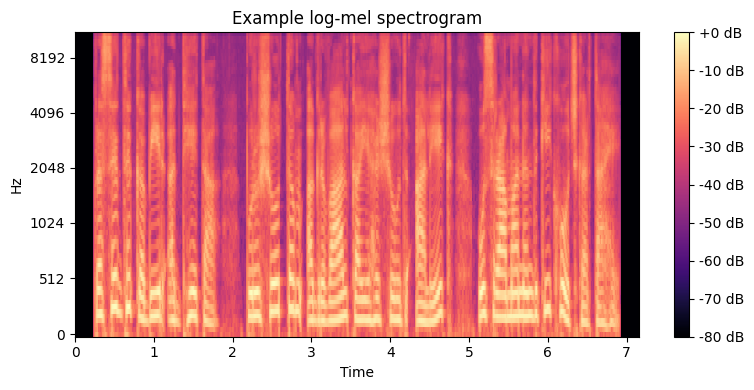

In [6]:
AUDIO_COL_CANDIDATES = [
    "audio_path",
    "wav_path",
    "file",
    "filepath",
    "filename",
    "audio",
    "clip",
    "utt_id",
]

detected_audio_col = None
for col in df.columns:
    if col.lower() in AUDIO_COL_CANDIDATES:
        detected_audio_col = col
        break

if detected_audio_col is None:
    raise ValueError(
        "Could not automatically detect the audio column.\n"
        "Please set 'detected_audio_col' manually to the correct column name from:\n"
        f"{df.columns.tolist()}"
    )

print(f"✅ Detected audio column: '{detected_audio_col}'")


# 2) Build full audio paths

def build_full_audio_path(rel_path):
    """
    Try a few reasonable ways to construct the full audio path.
    Assumes files are under DATA_DIR (often inside 'audio/' subfolder).
    """
    rel_path = str(rel_path)

    # Case 1: already an absolute path
    if os.path.isabs(rel_path) and os.path.exists(rel_path):
        return rel_path

    # Case 2: try DATA_DIR / rel_path
    candidate1 = os.path.join(DATA_DIR, rel_path)
    if os.path.exists(candidate1):
        return candidate1

    # Case 3: try DATA_DIR / "audio" / rel_path
    candidate2 = os.path.join(DATA_DIR, "audio", rel_path)
    if os.path.exists(candidate2):
        return candidate2

    # If nothing works, just return best guess (for debugging)
    return candidate2

df["audio_path"] = df[detected_audio_col].apply(build_full_audio_path)

print("\n📁 Example audio paths:")
display(df[["audio_path", "clean_text"]].head())


# 3) Audio → Mel-spectrogram config

SAMPLE_RATE = 22050   # standard for TTS
N_FFT = 1024
HOP_LENGTH = 256
WIN_LENGTH = 1024
N_MELS = 80
FMIN = 0
FMAX = SAMPLE_RATE // 2

print("\n🎚 Audio config:")
print(f"SAMPLE_RATE = {SAMPLE_RATE}, N_MELS = {N_MELS}")


# 4) Helper functions: load audio + mel

def load_wav(path, sr=SAMPLE_RATE):
    """Load mono audio, resample to fixed sample rate."""
    wav, orig_sr = librosa.load(path, sr=None, mono=True)
    if orig_sr != sr:
        wav = librosa.resample(wav, orig_sr=orig_sr, target_sr=sr)
    return wav


def wav_to_mel(wav, sr=SAMPLE_RATE):
    """Convert waveform → log-mel spectrogram."""
    # mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=1.0,  # magnitude
    )
    # log scale
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


# 5) Quick sanity check on one sample

sample_row = df.iloc[0]
sample_path = sample_row["audio_path"]

print("\n🧪 Sanity check on first audio file:")
print("Path:", sample_path)

if os.path.exists(sample_path):
    wav = load_wav(sample_path)
    mel = wav_to_mel(wav)

    print("Waveform shape:", wav.shape)
    print("Mel shape:", mel.shape)  # (n_mels, time_frames)

    # Plot mel
    plt.figure(figsize=(8, 4))
    librosa.display.specshow(
        mel,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title("Example log-mel spectrogram")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Sample audio file does NOT exist. Check paths / metadata.")


## Train/Val Split + Dataset + Collate + DataLoaders

In [7]:
# 1) Train / validation split (by rows)
all_indices = np.arange(len(df))
np.random.seed(42)
np.random.shuffle(all_indices)

train_ratio = 0.9
split_idx = int(train_ratio * len(all_indices))

train_idx = all_indices[:split_idx]
val_idx   = all_indices[split_idx:]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)

print(f" Train samples: {len(df_train)}")
print(f" Val samples:   {len(df_val)}")


# 2) Dataset class

class HindiTTSDataset(Dataset):
    def __init__(self, df, sample_rate=SAMPLE_RATE):
        self.df = df
        self.sample_rate = sample_rate

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # text sequence (list of ints)
        text_ids = row["text_ids"]

        # load audio + mel
        audio_path = row["audio_path"]
        wav = load_wav(audio_path, sr=self.sample_rate)
        mel = wav_to_mel(wav, sr=self.sample_rate)  # (n_mels, T)

        # convert to tensors
        text_ids = torch.tensor(text_ids, dtype=torch.long)
        mel = torch.tensor(mel, dtype=torch.float32)

        sample = {
            "text_ids": text_ids,
            "text_len": len(text_ids),
            "mel": mel,
            "mel_len": mel.shape[1],
            "audio_path": audio_path,
        }
        return sample


# 3) Collate function for padding within a batch

PAD_ID = char_to_id["<pad>"]

def collate_fn(batch):
    # sort by text length (optional but can help RNN efficiency)
    batch = sorted(batch, key=lambda x: x["text_len"], reverse=True)

    text_lens = torch.tensor([b["text_len"] for b in batch], dtype=torch.long)
    mel_lens  = torch.tensor([b["mel_len"]  for b in batch], dtype=torch.long)

    max_text_len = text_lens.max().item()
    max_mel_len  = mel_lens.max().item()

    # (batch, max_text_len)
    text_padded = torch.full(
        (len(batch), max_text_len), PAD_ID, dtype=torch.long
    )

    # (batch, n_mels, max_mel_len)
    mel_padded = torch.zeros(
        (len(batch), N_MELS, max_mel_len), dtype=torch.float32
    )

    for i, b in enumerate(batch):
        t = b["text_ids"]
        m = b["mel"]
        text_padded[i, :t.size(0)] = t
        mel_padded[i, :, :m.shape[1]] = m

    return {
        "text_ids": text_padded,
        "text_lens": text_lens,
        "mel": mel_padded,
        "mel_lens": mel_lens,
    }


# 4) Create DataLoaders

BATCH_SIZE = 2
NUM_WORKERS = 2

train_dataset = HindiTTSDataset(df_train)
val_dataset   = HindiTTSDataset(df_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# quick sanity check: fetch one batch
batch = next(iter(train_loader))
print(" One batch shapes:")
print("text_ids:", batch["text_ids"].shape)
print("mel:", batch["mel"].shape)
print("text_lens:", batch["text_lens"][:5])
print("mel_lens:", batch["mel_lens"][:5])

 Train samples: 10642
 Val samples:   1183
 One batch shapes:
text_ids: torch.Size([2, 198])
mel: torch.Size([2, 80, 1156])
text_lens: tensor([198,  98])
mel_lens: tensor([1156,  592])


##  Tacotron2 Acoustic Model — Overview

Our Hindi TTS system uses a Tacotron2-style architecture.  
This model converts **text IDs → mel-spectrograms**, which will later be fed into a vocoder (HiFi-GAN).

### Architecture Components

### **1. Encoder**
- Character embeddings
- 3× 1-D convolution layers (ReLU + BatchNorm)
- Bidirectional LSTM
- Produces encoded feature sequence

### **2. Location-Sensitive Attention**
- Uses cumulative + current attention
- Helps maintain monotonic left-to-right alignment
- Generates context vector for each decoder step

### **3. Decoder**
- Autoregressive mel generator
- Two LSTM layers
- Predicts:
  - mel frame (80 dims)
  - stop token (EOS)
- Uses teacher forcing during training

### **4. Postnet**
- 5-layer CNN to refine mel output
- Produces clearer, smoother spectrograms

### **5. Loss Functions**
- L1 mel loss
- Binary cross-entropy for stop token
- Optional guided attention loss

This model is trained with `(text_ids, mel, text_lens, mel_lens)` batches created earlier.
The output mel-spectrograms are later converted to waveforms using HiFi-GAN.


## Tacotron2 Model (Encoder + Attention + Decoder + Postnet)

### Encoder

Encoder — “Understanding the Text”

The encoder takes character IDs (`text_ids`) and produces a meaningful representation for every character.

### **1. Embedding Layer**
- Each Hindi character (क, ख, ि, ्…) is mapped to a 256-dimensional vector.
- Helps the model learn a continuous meaning representation of characters.

### **2. Convolution Layers (3×)**
Each is:
Conv1D → BatchNorm → ReLU

sql
Copy code
- Captures short-range patterns from text  
- Learns common Hindi grapheme structures like “कि”, “त्र”, “व्य”, “ज्ञा”

### **3. Bidirectional LSTM**
- Reads the text left-to-right **and** right-to-left  
- Produces a 512-dim sequence containing full-context representation

**Final encoder output shape:**  

In [8]:
try:
    del model
    torch.cuda.empty_cache()
except NameError:
    torch.cuda.empty_cache()


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, encoder_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)

        self.conv1 = nn.Sequential(
            nn.Conv1d(embed_dim, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
        )

        self.bilstm = nn.LSTM(
            input_size=256,
            hidden_size=encoder_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

    def forward(self, text_ids):
        # text_ids: (B, T_text)
        emb = self.embedding(text_ids)          # (B, T_text, embed_dim)
        x = emb.transpose(1, 2)                 # (B, embed_dim, T_text)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.transpose(1, 2)                   # (B, T_text, 256)

        outputs, _ = self.bilstm(x)             # (B, T_text, encoder_dim)
        return outputs


### Attention

In [9]:
class LocationSensitiveAttention(nn.Module):
    def __init__(self, query_dim=512, encoder_dim=256, attn_dim=64):
        super().__init__()

        self.query_layer = nn.Linear(query_dim, attn_dim, bias=False)
        self.memory_layer = nn.Linear(encoder_dim, attn_dim, bias=False)
        self.location_conv = nn.Conv1d(1, attn_dim, kernel_size=31, padding=15)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, query, encoder_out, cumulative_attn):
        # query: (B, query_dim)
        # encoder_out: (B, T_text, encoder_dim)
        # cumulative_attn: (B, T_text)

        processed_query = self.query_layer(query).unsqueeze(1)       # (B, 1, attn_dim)
        processed_memory = self.memory_layer(encoder_out)            # (B, T_text, attn_dim)

        loc_feat = self.location_conv(cumulative_attn.unsqueeze(1))  # (B, attn_dim, T_text)
        loc_feat = loc_feat.transpose(1, 2)                          # (B, T_text, attn_dim)

        energies = self.v(torch.tanh(processed_query + processed_memory + loc_feat)).squeeze(-1)
        attn = F.softmax(energies, dim=-1)                           # (B, T_text)

        context = torch.bmm(attn.unsqueeze(1), encoder_out).squeeze(1)  # (B, encoder_dim)
        return context, attn


### Decoder

The decoder generates audio **one time step at a time**, so it must focus on the correct text character.

### **How attention works:**
1. **Query** = current decoder state  
2. **Memory** = encoder outputs  
3. **Location features** = previous attention distribution  
4. **Energy computation** = how relevant each text position is  
5. **Softmax → Attention weights**  
6. **Context vector** = weighted sum of encoder outputs  

This ensures:
- No skipping characters  
- No repeating characters  
- Natural left-to-right reading



In [10]:
class Decoder(nn.Module):
    def __init__(self, encoder_dim=256, prenet_dim=128, decoder_dim=512, n_mels=80):
        super().__init__()

        self.n_mels = n_mels

        self.prenet = nn.Sequential(
            nn.Linear(n_mels, prenet_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(prenet_dim, prenet_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
        )

        self.lstm1 = nn.LSTMCell(prenet_dim + encoder_dim, decoder_dim)
        self.lstm2 = nn.LSTMCell(decoder_dim, decoder_dim)

        self.attention = LocationSensitiveAttention(
            query_dim=decoder_dim, encoder_dim=encoder_dim, attn_dim=64
        )

        self.mel_proj = nn.Linear(decoder_dim + encoder_dim, n_mels)
        self.stop_proj = nn.Linear(decoder_dim + encoder_dim, 1)

    def forward(self, encoder_out, mel_targets):
        B, T_text, _ = encoder_out.size()
        B, n_mels, T_mel = mel_targets.size()

        mel_targets = mel_targets.transpose(1, 2)  # (B, T_mel, n_mels)

        h1 = torch.zeros(B, 512, device=device)
        c1 = torch.zeros(B, 512, device=device)
        h2 = torch.zeros(B, 512, device=device)
        c2 = torch.zeros(B, 512, device=device)

        cumulative_attn = torch.zeros(B, T_text, device=device)

        mel_outputs = []
        stop_outputs = []

        prev_mel = mel_targets[:, 0, :]  # first frame as input

        for t in range(T_mel):
            prenet_out = self.prenet(prev_mel)

            context, attn = self.attention(h2, encoder_out, cumulative_attn)
            cumulative_attn = cumulative_attn + attn

            h1, c1 = self.lstm1(torch.cat([prenet_out, context], dim=1), (h1, c1))
            h2, c2 = self.lstm2(h1, (h2, c2))

            decoder_state = torch.cat([h2, context], dim=1)

            mel_frame = self.mel_proj(decoder_state)
            stop_token = self.stop_proj(decoder_state)

            mel_outputs.append(mel_frame)
            stop_outputs.append(stop_token)

            prev_mel = mel_targets[:, t, :]

        mel_outputs = torch.stack(mel_outputs, dim=1)    # (B, T_mel, n_mels)
        stop_outputs = torch.stack(stop_outputs, dim=1)  # (B, T_mel, 1)

        return mel_outputs.transpose(1, 2), stop_outputs.squeeze(-1)


### Postnet

 Processes the previous mel frame  
- Makes the model robust  
- Encourages stable prosody  

### **2. LSTM Stack**
Two LSTMCell layers update the speech generation state.

### **3. Attention + Decoder State**
- Attention chooses *where* to focus  
- Decoder predicts the next mel frame

### **4. Mel Projection**
Generates a **80-dim mel-spectrogram frame**.

### **5. Stop Token**
Predicts:
- `1` → stop speaking  
- `0` → continue  

This helps the model decide where to end audio.

---

### Postnet — “Mel Spectrogram Enhancer”

The Postnet consists of **5 convolutional layers**.

### Purpose:
- Sharpen harmonics  
- Add fine spectral details  
- Improve clarity and naturalness  

Final mel =  

In [11]:
class Postnet(nn.Module):
    def __init__(self, n_mels=80, hidden_channels=256):
        super().__init__()
        layers = [
            nn.Sequential(
                nn.Conv1d(n_mels, hidden_channels, kernel_size=5, padding=2),
                nn.BatchNorm1d(hidden_channels),
                nn.Tanh(),
                nn.Dropout(0.5),
            )
        ]
        for _ in range(3):
            layers.append(
                nn.Sequential(
                    nn.Conv1d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
                    nn.BatchNorm1d(hidden_channels),
                    nn.Tanh(),
                    nn.Dropout(0.5),
                )
            )
        layers.append(
            nn.Sequential(
                nn.Conv1d(hidden_channels, n_mels, kernel_size=5, padding=2),
                nn.BatchNorm1d(n_mels),
                nn.Dropout(0.5),
            )
        )
        self.net = nn.Sequential(*layers)

    def forward(self, mel):
        return self.net(mel)


### Tacotron2 (full model)

In [12]:
class Tacotron2(nn.Module):
    def __init__(self, vocab_size, n_mels=80):
        super().__init__()
        self.encoder = Encoder(vocab_size=vocab_size, embed_dim=128, encoder_dim=256)
        self.decoder = Decoder(encoder_dim=256, prenet_dim=128, decoder_dim=512, n_mels=n_mels)
        self.postnet = Postnet(n_mels=n_mels, hidden_channels=256)

    def forward(self, text_ids, mel_targets):
        encoder_out = self.encoder(text_ids)
        mel_out, stop_out = self.decoder(encoder_out, mel_targets)
        mel_post = mel_out + self.postnet(mel_out)
        return mel_out, mel_post, stop_out

In [13]:
# create small model and move to GPU

torch.cuda.empty_cache()

model = Tacotron2(
    vocab_size=len(vocab),
    n_mels=N_MELS
).to(device)

print("Model parameters (millions):", sum(p.numel() for p in model.parameters()) / 1e6)

Model parameters (millions): 6.498561


## Tacotron2 Training Loop

In [14]:
# Initialize model
model = Tacotron2(
    vocab_size=len(vocab),
    n_mels=N_MELS
).to(device)

print("Model parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

torch.cuda.empty_cache()


# Loss Functions
mel_loss_fn = nn.L1Loss()
stop_loss_fn = nn.BCEWithLogitsLoss()


# Optimizer + Scheduler + AMP
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=5000, gamma=0.998
)

scaler = GradScaler()


# Training / Validation Loop
EPOCHS = 10
log_every = 50
save_every = 1

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    print(f"\nEpoch {epoch}/{EPOCHS}")

    for batch_idx, batch in enumerate(tqdm(train_loader)):
        text_ids = batch["text_ids"].to(device)
        mel_targets = batch["mel"].to(device)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward
        with autocast():
            mel_pred, mel_post, stop_pred = model(text_ids, mel_targets)

            mel_targets_trim = mel_targets[:, :, :mel_pred.size(2)]

            mel_l1 = mel_loss_fn(mel_post, mel_targets_trim)

            stop_targets = torch.zeros_like(stop_pred).to(device)
            stop_targets[:, -1] = 1

            stop_ce = stop_loss_fn(stop_pred, stop_targets)

            loss = mel_l1 + 0.1 * stop_ce

        # Backpropagation with AMP
        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        running_loss += loss.item()

        if (batch_idx + 1) % log_every == 0:
            print(f"Step {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    print(f"Epoch {epoch} Train Loss: {train_loss:.4f}")

    # Validation
    model.eval()
    val_running = 0.0

    with torch.no_grad():
        for batch in val_loader:
            text_ids = batch["text_ids"].to(device)
            mel_targets = batch["mel"].to(device)

            with autocast():
                mel_pred, mel_post, stop_pred = model(text_ids, mel_targets)
                mel_targets_trim = mel_targets[:, :, :mel_pred.size(2)]

                mel_l1 = mel_loss_fn(mel_post, mel_targets_trim)

                stop_targets = torch.zeros_like(stop_pred).to(device)
                stop_targets[:, -1] = 1

                stop_ce = stop_loss_fn(stop_pred, stop_targets)

                val_loss = mel_l1 + 0.1 * stop_ce

            val_running += val_loss.item()

    val_loss = val_running / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch} Val Loss: {val_loss:.4f}")

    # Save Checkpoint
    if epoch % save_every == 0:
        ckpt_path = f"tacotron2_epoch_{epoch}.pt"
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "vocab": vocab,
        }, ckpt_path)

        print(f"Saved checkpoint: {ckpt_path}")

print("\nTraining Finished.")


Model parameters: 6.498561 M

Epoch 1/10


  0%|          | 0/5321 [00:00<?, ?it/s]

Step 50/5321 | Loss: 10.5898
Step 100/5321 | Loss: 4.6039
Step 150/5321 | Loss: 6.5452
Step 200/5321 | Loss: 5.5780


KeyboardInterrupt: 

It'll Take time may be 2 or 3 days

In [ ]:
torch.save(model.state_dict(), "tacotron2_hindi_final.pt")
